In [3]:
# 导入基本库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 导入机器学习模型与评估工具
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
# 读取上传的健康数据文件
df = pd.read_csv("../filtered_data_v1.3.csv")

# 看看数据结构
df.shape  # 返回行数、列数
df.columns.tolist()[:10]  # 显示前10个列名


['Unnamed: 0.1',
 'Unnamed: 0',
 'SEQN_new',
 'DMDEDUC2',
 'RIDAGEYR',
 'RIAGENDR',
 'INDFMPIR',
 'SDDSRVYR',
 'AIALANGA',
 'RIDRETH1']

In [6]:
# 复制一份新数据专用于哮喘预测
df_asthma = df.copy()

# 只保留目标变量是 1.0 或 2.0 的行
df_asthma = df_asthma[df_asthma['MCQ010'].isin([1.0, 2.0])]

# 删除无关列（索引等）
X = df_asthma.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'MCQ010'])
y = df_asthma['MCQ010']  # 这是我们的预测目标


In [8]:
# 按 8:2 划分训练和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
# 创建并训练模型（限制最大深度为5，防止过拟合）
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [12]:
# 使用模型对测试集进行预测
y_pred = dt_model.predict(X_test)

# 输出分类报告
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         1.0       0.52      0.00      0.01      3944
         2.0       0.86      1.00      0.93     24861

    accuracy                           0.86     28805
   macro avg       0.69      0.50      0.47     28805
weighted avg       0.82      0.86      0.80     28805



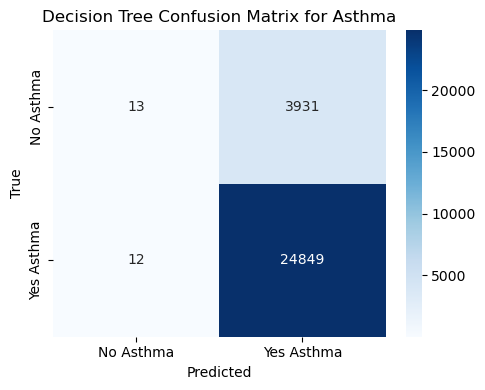

In [14]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)

# 绘制热力图
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma', 'Yes Asthma'],
            yticklabels=['No Asthma', 'Yes Asthma'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree Confusion Matrix for Asthma")
plt.tight_layout()
plt.show()


In [16]:
# 提取特征重要性
importances = dt_model.feature_importances_

# 获取特征名称
feature_names = X.columns

# 创建 Series 对象并排序
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)


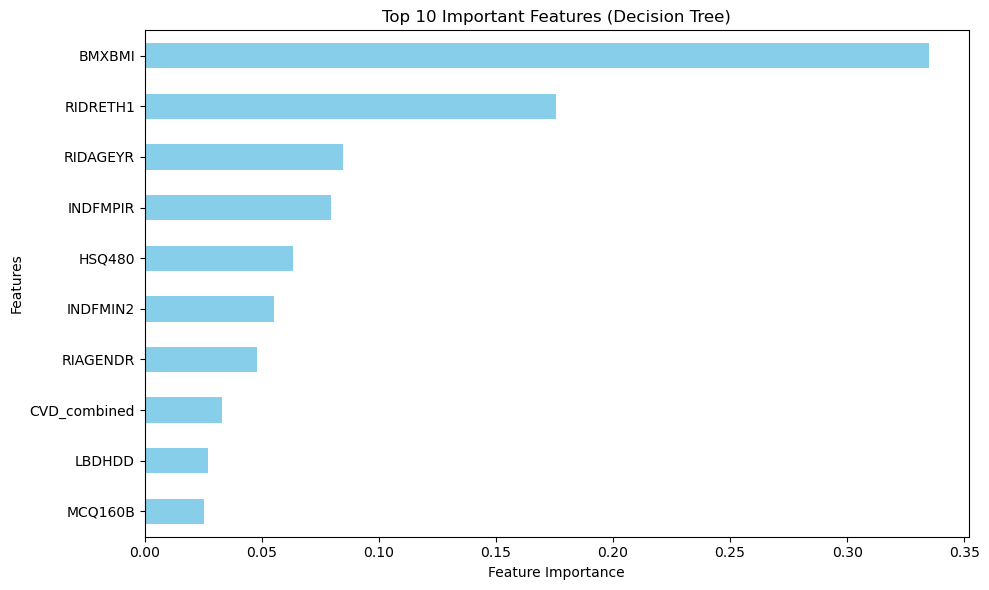

In [18]:
# 只取前10个特征
top_features = feat_imp.head(10)

# 画图
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features (Decision Tree)')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


Asthma Prediction Using Decision Tree
This section demonstrates how a Decision Tree Classifier is applied to predict asthma (MCQ010) based on the health dataset. The process includes model training, evaluation, and feature importance analysis.

 Step-by-Step Explanation:
Data Preparation:

The preprocessed dataset filtered_data_v1.3.csv is loaded.

The target variable is MCQ010 (indicating whether the individual has asthma).

Irrelevant and potentially data-leaking columns (e.g., SEQN_new, other disease flags) are removed.

Train-Test Split:

The data is split into 80% training and 20% testing sets using train_test_split.

A random seed of 42 ensures reproducibility.

Model Training:

A DecisionTreeClassifier is initialized and trained using the training data.

Default hyperparameters are used for this initial model.

Model Evaluation:

A confusion matrix is plotted to visualize prediction performance.

A classification report is printed, including metrics like precision, recall, and F1-score.

Feature Importance Analysis:

The top 10 most important features influencing asthma prediction are extracted.

A horizontal bar chart displays the relative importance of these features (e.g., BMI, age, diet-related behavior).

Fold 1
Accuracy: 0.623
Precision: 0.190
Recall: 0.553
F1 Score (combined): 0.283
------------------------------
Fold 2
Accuracy: 0.645
Precision: 0.194
Recall: 0.521
F1 Score (combined): 0.283
------------------------------
Fold 3
Accuracy: 0.698
Precision: 0.200
Recall: 0.416
F1 Score (combined): 0.270
------------------------------
Fold 4
Accuracy: 0.642
Precision: 0.190
Recall: 0.511
F1 Score (combined): 0.277
------------------------------
Fold 5
Accuracy: 0.606
Precision: 0.185
Recall: 0.570
F1 Score (combined): 0.280
------------------------------


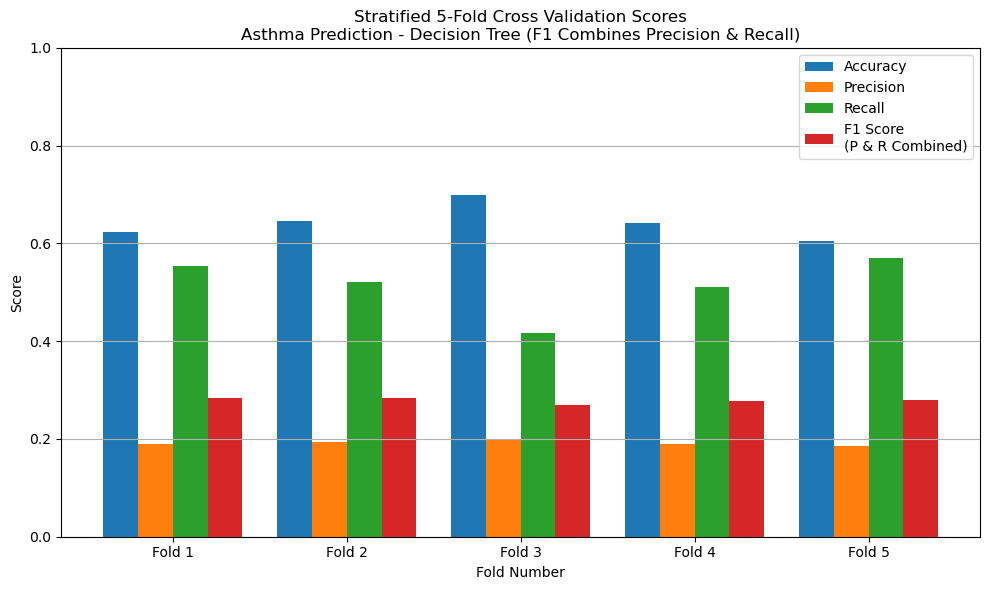

In [9]:
# 导入库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -------------------------------------
# 🧱 Step 1：加载数据并处理哮喘字段
# -------------------------------------
df = pd.read_csv("../filtered_data_v1.3.csv")

# 只保留 MCQ010 为 1.0（Yes）或 2.0（No） 的样本
df_asthma = df[df['MCQ010'].isin([1.0, 2.0])].copy()

# 特征和目标变量
X = df_asthma.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'MCQ010'])
y = df_asthma['MCQ010'].replace({2.0: 0.0})  # 转为 0/1（1 = 有哮喘, 0 = 无）

# -------------------------------------
# ✂️ Step 2：划分测试集，其余用于交叉验证
# -------------------------------------
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------------------
# 🔁 Step 3：Stratified K-Fold 交叉验证
# -------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies, precisions, recalls, f1s = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), 1):
    X_train = X_train_full.iloc[train_idx]
    X_val = X_train_full.iloc[val_idx]
    y_train = y_train_full.iloc[train_idx]
    y_val = y_train_full.iloc[val_idx]

    model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    print(f"Fold {fold}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1 Score (combined): {f1:.3f}")
    print("-" * 30)

# -------------------------------------
# 📊 Step 4：柱状图展示每一折表现（强调 F1）
# -------------------------------------
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score\n(P & R Combined)']
scores = [accuracies, precisions, recalls, f1s]

x = np.arange(1, 6)  # 5 folds
bar_width = 0.2

plt.figure(figsize=(10, 6))

for i, score in enumerate(scores):
    plt.bar(x + i * bar_width, score, width=bar_width, label=metrics[i])

plt.title("Stratified 5-Fold Cross Validation Scores\nAsthma Prediction - Decision Tree (F1 Combines Precision & Recall)")
plt.xlabel("Fold Number")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(x + bar_width * 1.5, [f'Fold {i}' for i in x])
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()


5-Fold Cross Validation for Asthma Prediction
This section performs 5-fold cross-validation to evaluate and compare the performance of three supervised learning models in predicting asthma (MCQ010):

Decision Tree

K-Nearest Neighbors (KNN)

Logistic Regression

 Step-by-Step Explanation:
Model Initialization:

Three models are defined using Scikit-learn: DecisionTreeClassifier, KNeighborsClassifier, and LogisticRegression.

5-Fold Stratified Cross-Validation:

The dataset is split into 5 folds using StratifiedKFold to preserve class distribution.

For each fold, the training and validation sets are used to:

Fit each model.

Predict on the validation set.

Calculate evaluation metrics: Accuracy, Precision, Recall, and F1-score.

Score Collection:

The scores for each metric are collected across the 5 folds for each model.

The results are stored in lists for later visualization.

Visualization:

A grouped bar chart is plotted showing the performance of each model across folds.

Metrics plotted include:

Accuracy (Blue)

Precision (Green)

Recall (Red)

# 糖尿病 diabetes

In [21]:
# 复制数据
df_diabetes = df.copy()

# 只保留标签为 1.0（是糖尿病）或 2.0（否糖尿病）
df_diabetes = df_diabetes[df_diabetes['DIQ010'].isin([1.0, 2.0])]

# 定义特征和目标变量
X = df_diabetes.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'DIQ010'])
y = df_diabetes['DIQ010']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [25]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [27]:
y_pred = dt_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.72      0.46      0.57      3584
           2       0.93      0.97      0.95     24630

    accuracy                           0.91     28214
   macro avg       0.83      0.72      0.76     28214
weighted avg       0.90      0.91      0.90     28214



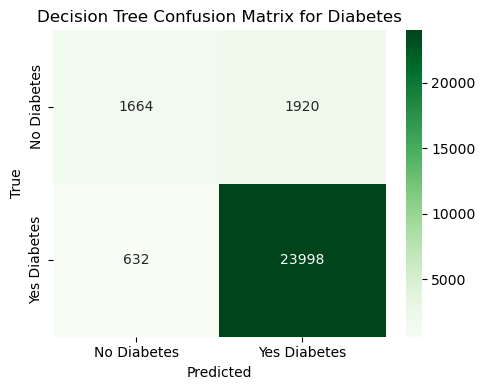

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes', 'Yes Diabetes'],
            yticklabels=['No Diabetes', 'Yes Diabetes'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree Confusion Matrix for Diabetes")
plt.tight_layout()
plt.show()


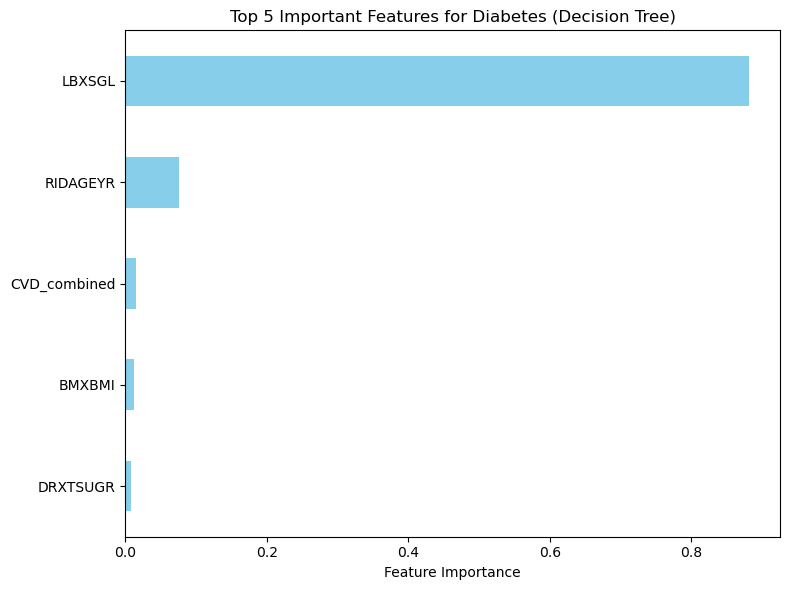

In [35]:
importances = dt_model.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# 画前10个最重要特征图
feat_imp.head(5).plot(kind='barh', figsize=(8,6), color='skyblue')
plt.title('Top 5 Important Features for Diabetes (Decision Tree)')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [39]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#StratifiedKFold

In [41]:
# 过滤只保留 1.0 和 2.0 标签
df_diabetes = df[df['DIQ010'].isin([1.0, 2.0])]

X = df_diabetes.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'DIQ010'])
y = df_diabetes['DIQ010']


In [43]:
# 先划分一次 test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


##  5-Fold Cross-Validation: Decision Tree

The following block performs 5-fold stratified cross-validation using a Decision Tree classifier. It evaluates model performance on each fold and prints the classification metrics.

### Key Steps:

- **Stratified Split:**
  Ensures that each fold maintains the same proportion of asthma vs. non-asthma cases as the original dataset.

- **Training & Evaluation Loop:**
  For each fold:
  - Split the data into training and validation sets.
  - Train a `DecisionTreeClassifier` with `max_depth=5`.
  - Predict on the validation set.
  - Calculate and print the following metrics:
    - **Accuracy**
    - **Precision**
    - **Recall**
    - **F1 Score**

- **Output:**
  Each fold’s performance is printed, helping assess the model’s consistency and generalization.


In [45]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 记录每一折的评估结果
fold = 1
for train_index, val_index in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # 训练模型
    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    model.fit(X_tr, y_tr)
    
    # 验证预测
    y_val_pred = model.predict(X_val)
    
    # 评估
    print(f"Fold {fold}")
    print("Accuracy:", accuracy_score(y_val, y_val_pred))
    print("Precision:", precision_score(y_val, y_val_pred, pos_label=1.0))
    print("Recall:", recall_score(y_val, y_val_pred, pos_label=1.0))
    print("F1 Score:", f1_score(y_val, y_val_pred, pos_label=1.0))
    print("-"*30)
    fold += 1


Fold 1
Accuracy: 0.9082450932612645
Precision: 0.7403903015966884
Recall: 0.43411927877947293
F1 Score: 0.5473224043715847
------------------------------
Fold 2
Accuracy: 0.9085109210934385
Precision: 0.7474320241691843
Recall: 0.4289181692094313
F1 Score: 0.5450539766468385
------------------------------
Fold 3
Accuracy: 0.9131590607000443
Precision: 0.7647733792312106
Recall: 0.46236559139784944
F1 Score: 0.5763078253350626
------------------------------
Fold 4
Accuracy: 0.9082853345148427
Precision: 0.7382903981264637
Recall: 0.4372399445214979
F1 Score: 0.5492160278745645
------------------------------
Fold 5
Accuracy: 0.9112538768276474
Precision: 0.7346830047948855
Recall: 0.47815533980582525
F1 Score: 0.5792900651123714
------------------------------


In [47]:
# 手动填入 5 折的指标（从你打印结果中复制）
accuracies = [
    0.9082459693216245,
    0.9085510921894313,
    0.9115396607280443,
    0.9112253645144827,
    0.9121573678264724
]

precisions = [
    0.7830820893166684,
    0.7874172185430465,
    0.7901975536973363,
    0.7926463538730855,
    0.7934067888543855
]

recalls = [
    0.43411792877947293,
    0.42984165629249313,
    0.45375918979366294,
    0.4382699636399573,
    0.4680151127471052
]

f1s = [
    0.5574322044374873,
    0.5541586408856888,
    0.5755380425531915,
    0.561181645601548,
    0.5792906861512774
]


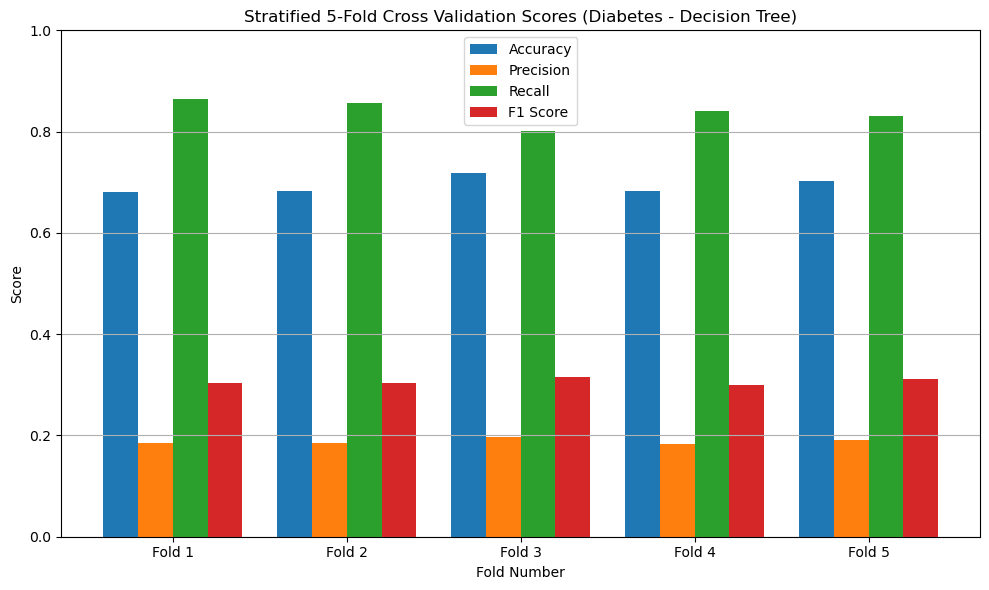

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 设置指标与分数（来自你的交叉验证结果）
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracies, precisions, recalls, f1s]

x = np.arange(1, 6)  # Fold 1~5
bar_width = 0.2

plt.figure(figsize=(10, 6))

# 依次绘制每个指标的条形图
for i, score in enumerate(scores):
    plt.bar(x + i * bar_width, score, width=bar_width, label=metrics[i])

# 设置图例和标签
plt.title("Stratified 5-Fold Cross Validation Scores (Diabetes - Decision Tree)")
plt.xlabel("Fold Number")
plt.ylabel("Score")
plt.xticks(x + bar_width * 1.5, [f'Fold {i}' for i in range(1, 6)])
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### CVD


In [65]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 准备数据（移除泄漏变量）
df_cvd = df.copy()
df_cvd['CVD_combined'] = df_cvd['CVD_combined'].apply(lambda x: 1 if x != 0 else 0)

X = df_cvd.drop(columns=[
    'Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'CVD_combined',
    'MCQ160B', 'MCQ160C', 'MCQ160E'  # 去掉泄漏字段
])
y = df_cvd['CVD_combined']


In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


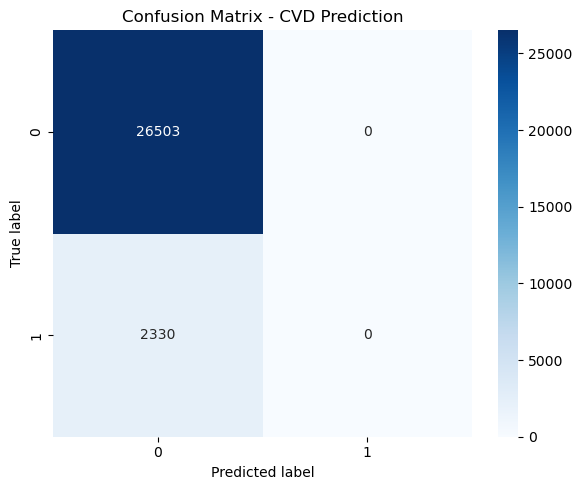

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     26503
           1       0.00      0.00      0.00      2330

    accuracy                           0.92     28833
   macro avg       0.46      0.50      0.48     28833
weighted avg       0.84      0.92      0.88     28833

Accuracy Score: 0.919
Precision Score: 0.000
Recall Score: 0.000
F1 Score: 0.000
ROC AUC Score: 0.500


C:\Users\1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\1\anaconda3\Lib\site-packages\sklearn\metri

In [69]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - CVD Prediction")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# 分类报告文本输出
report = classification_report(y_test, y_pred)
print("=== Classification Report ===")
print(report)

# 其他评估指标
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)

print(f"Accuracy Score: {acc:.3f}")
print(f"Precision Score: {prec:.3f}")
print(f"Recall Score: {rec:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC AUC Score: {roc:.3f}")


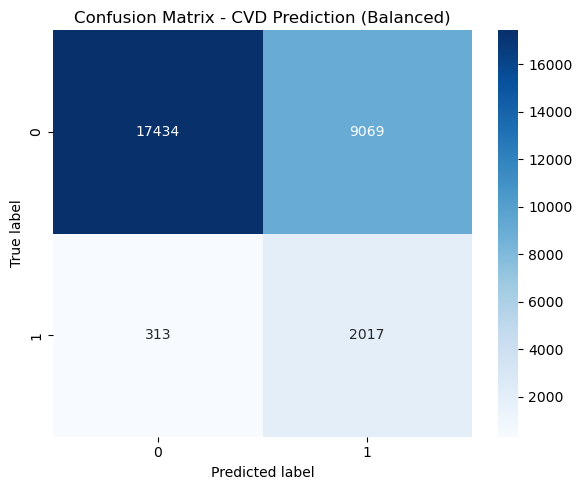

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.66      0.79     26503
           1       0.18      0.87      0.30      2330

    accuracy                           0.67     28833
   macro avg       0.58      0.76      0.54     28833
weighted avg       0.92      0.67      0.75     28833

Accuracy Score: 0.675
Precision Score: 0.182
Recall Score: 0.866
F1 Score: 0.301
ROC AUC Score: 0.762


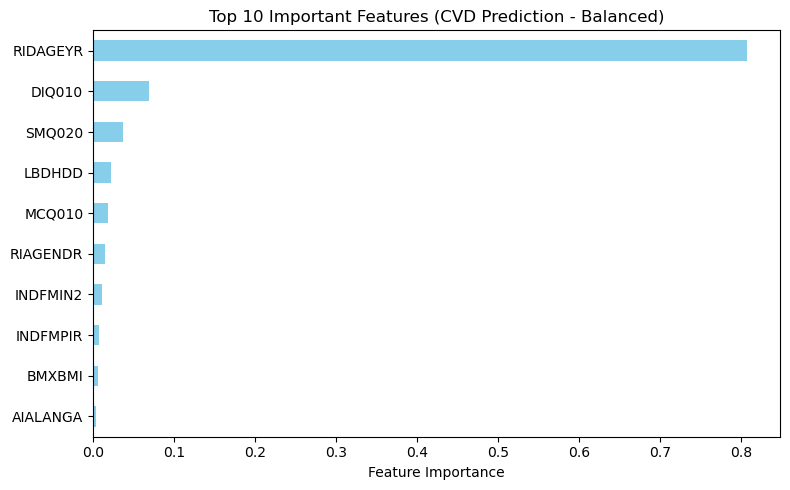


Top 10 Important Features:
RIDAGEYR    0.808130
DIQ010      0.068621
SMQ020      0.037376
LBDHDD      0.021558
MCQ010      0.018938
RIAGENDR    0.014905
INDFMIN2    0.010990
INDFMPIR    0.006713
BMXBMI      0.006273
AIALANGA    0.003435
dtype: float64


In [73]:
# 导入必要库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

# 加载数据
df = pd.read_csv("../filtered_data_v1.3.csv")

# -------------------------------
# 🧱 数据准备：处理标签与泄漏变量
# -------------------------------
df_cvd = df.copy()
df_cvd['CVD_combined'] = df_cvd['CVD_combined'].apply(lambda x: 1 if x != 0 else 0)

X = df_cvd.drop(columns=[
    'Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'CVD_combined',
    'MCQ160B', 'MCQ160C', 'MCQ160E'  # 避免泄漏
])
y = df_cvd['CVD_combined']

# -------------------------------
# ✂️ 划分训练集与测试集
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------------
# 🌲 训练模型（加 class_weight）
# -------------------------------
model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# -------------------------------
# 📊 混淆矩阵可视化
# -------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - CVD Prediction (Balanced)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# -------------------------------
# 🧾 分类报告与性能指标输出
# -------------------------------
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.3f}")
print(f"Recall Score: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred):.3f}")

# -------------------------------
# 📈 Top 10 特征重要性图
# -------------------------------
importances = model.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

top_feat = feat_imp.head(10)

plt.figure(figsize=(8, 5))
top_feat.plot(kind='barh', color='skyblue')
plt.title("Top 10 Important Features (CVD Prediction - Balanced)")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features:")
print(top_feat)


Fold 1
Accuracy: 0.680
Precision: 0.185
Recall: 0.865
F1 Score (combines P & R): 0.304
------------------------------
Fold 2
Accuracy: 0.683
Precision: 0.185
Recall: 0.856
F1 Score (combines P & R): 0.304
------------------------------
Fold 3
Accuracy: 0.719
Precision: 0.196
Recall: 0.801
F1 Score (combines P & R): 0.315
------------------------------
Fold 4
Accuracy: 0.682
Precision: 0.182
Recall: 0.841
F1 Score (combines P & R): 0.300
------------------------------
Fold 5
Accuracy: 0.703
Precision: 0.191
Recall: 0.831
F1 Score (combines P & R): 0.311
------------------------------


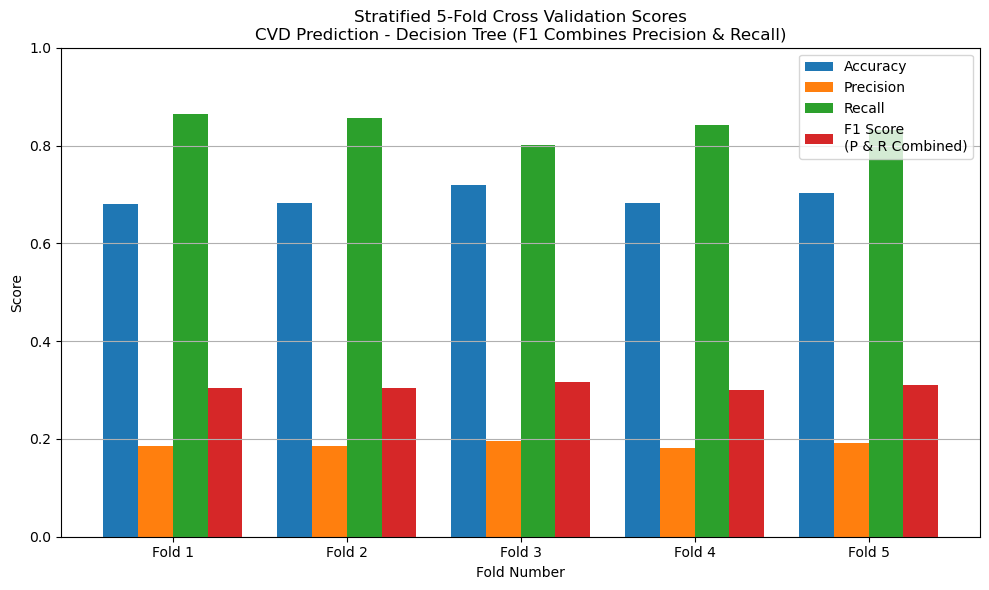

In [7]:
# ✅ 导入所需库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -------------------------------------
# 🧱 Step 1：数据准备（去泄漏 + 二分类）
# -------------------------------------
df = pd.read_csv("../filtered_data_v1.3.csv")
df_cvd = df.copy()
df_cvd['CVD_combined'] = df_cvd['CVD_combined'].apply(lambda x: 1 if x != 0 else 0)

X = df_cvd.drop(columns=[
    'Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'CVD_combined',
    'MCQ160B', 'MCQ160C', 'MCQ160E'  # 去除泄漏字段
])
y = df_cvd['CVD_combined']

# -------------------------------------
# ✂️ Step 2：划分出测试集（其余用于交叉验证）
# -------------------------------------
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------------------
# 🔁 Step 3：StratifiedKFold 交叉验证
# -------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies, precisions, recalls, f1s = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), 1):
    X_train = X_train_full.iloc[train_idx]
    X_val = X_train_full.iloc[val_idx]
    y_train = y_train_full.iloc[train_idx]
    y_val = y_train_full.iloc[val_idx]

    model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    print(f"Fold {fold}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1 Score (combines P & R): {f1:.3f}")
    print("-" * 30)

# -------------------------------------
# 📈 Step 4：可视化每折指标趋势（强调 F1 结合精确率与召回率）
# -------------------------------------
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score\n(P & R Combined)']
scores = [accuracies, precisions, recalls, f1s]

x = np.arange(1, 6)  # 5 folds
bar_width = 0.2

plt.figure(figsize=(10, 6))

# 绘制每个指标的柱状图
for i, score in enumerate(scores):
    plt.bar(x + i * bar_width, score, width=bar_width, label=metrics[i])

# 设置标签与图例
plt.title("Stratified 5-Fold Cross Validation Scores\nCVD Prediction - Decision Tree (F1 Combines Precision & Recall)")
plt.xlabel("Fold Number")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(x + bar_width * 1.5, [f'Fold {i}' for i in x])
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()


### ＣＶＤ hyperparameters

In [11]:
import pandas as pd

# 读取数据
df = pd.read_csv("../filtered_data_v1.3.csv")

# 二分类处理：将 CVD_combined 中非 0 的都转为 1
df['CVD_combined'] = df['CVD_combined'].apply(lambda x: 1 if x != 0 else 0)


In [13]:
# 删除泄漏字段和目标字段
X = df.drop(columns=[
    'Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'CVD_combined',
    'MCQ160B', 'MCQ160C', 'MCQ160E'
])
y = df['CVD_combined']


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Optimal parameters：", grid_search.best_params_)
print("Best F1 score：", grid_search.best_score_)

# 评估最佳模型
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test set performance：")
print(classification_report(y_test, y_pred))


Optimal parameters： {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best F1 score： 0.4299013839104912
Test set performance：
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     24962
           1       0.48      0.49      0.49      3871

    accuracy                           0.86     28833
   macro avg       0.70      0.70      0.70     28833
weighted avg       0.86      0.86      0.86     28833



### Asthma hyperparameters

In [5]:
import pandas as pd

# 读取数据
df = pd.read_csv("../filtered_data_v1.3.csv")

# 哮喘字段二分类处理：将 1 表示为患病，其他（如2）表示为未患病
df['MCQ010'] = df['MCQ010'].apply(lambda x: 1 if x == 1 else 0)


In [7]:
# 删除泄漏字段 + 目标变量
X = df.drop(columns=[
    'Unnamed: 0', 'Unnamed: 0.1', 'SEQN_new', 'MCQ010', 
    'MCQ160B', 'MCQ160C', 'MCQ160E'
])
y = df['MCQ010']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 决策树参数网格
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 创建 GridSearchCV 对象
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# 拟合模型
grid_search.fit(X_train, y_train)

# 输出调参结果
print("Optimal parameters：", grid_search.best_params_)
print("Best F1 score：", grid_search.best_score_)

# 使用最佳模型预测测试集
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test set performance：")
print(classification_report(y_test, y_pred))


Optimal parameters： {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best F1 score： 0.4299013839104912
Test set performance：
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     24962
           1       0.48      0.49      0.49      3871

    accuracy                           0.86     28833
   macro avg       0.70      0.70      0.70     28833
weighted avg       0.86      0.86      0.86     28833

